# Winoground / Evaluating CLIP — Defensa MCC225
**Niels Pacheco** · Cuadernos C5, C8, C10

**Idea:** ¿CLIP *entiende* la escena o solo *empareja*?
**Tesis:** retrieval alto **≠** composición → Recall@K alto, **group ≈ azar**.
Motor = OpenCLIP (C10); el *porqué* = fusión profunda (C5) y atención crossmodal (C8); al final **entreno** un re-ranker con validación cruzada (la mejora, C6).

*En vivo mostraré:* celda 1 (entorno), 4 (scorer), 6 (validación), 5 (resultado). El resto es profundidad para preguntas.

## 1. Entorno (trazabilidad)

In [1]:
import os, sys, pathlib, json, re, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name=='notebooks' else pathlib.Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
from src.env_logging import print_snapshot
_ = print_snapshot(ROOT)

/Users/nielspacheco/Desktop/Classes/UNI/Maestria en ciencias Computacion/IA generativa y multimodal/MCC225-ExamenParcial-Winoground/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HOJA DE TRAZABILIDAD — ENTORNO DE EJECUCIÓN (MCC225)
           python : 3.12.11
         platform : macOS-26.1-arm64-arm-64bit
     git_revision : e22ab9c
           device : mps (Apple Silicon)
            torch : 2.5.1
  open_clip_torch : 3.3.0
     transformers : 5.12.0
         datasets : 5.0.0
            numpy : 2.1.3
            faiss : 1.14.3


## 2. Datos
Cada ejemplo: 2 imágenes + 2 captions con **las mismas palabras en otro orden**. Convención `caption_0 ↔ image_0`.

In [2]:
from src.winoground_data import load_dataset
examples, source = load_dataset(prefer_real=True)
N = len(examples)
print('fuente:', source, '| N =', N)
tags = [e.tag for e in examples]
pd.Series(tags).value_counts()

fuente: winoground_real | N = 400


Relation    233
Object      141
Both         26
Name: count, dtype: int64

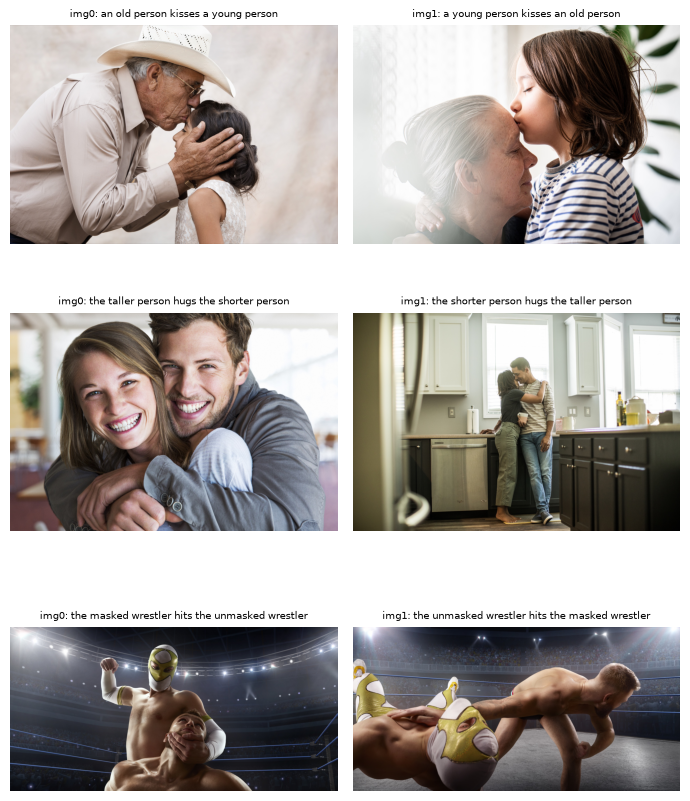

In [3]:
fig, ax = plt.subplots(3, 2, figsize=(7, 9))
for r, k in enumerate([0, 1, 2]):
    e = examples[k]
    ax[r,0].imshow(e.image_0); ax[r,0].set_title(f'img0: {e.caption_0}', fontsize=7); ax[r,0].axis('off')
    ax[r,1].imshow(e.image_1); ax[r,1].set_title(f'img1: {e.caption_1}', fontsize=7); ax[r,1].axis('off')
plt.tight_layout(); plt.show()

## 3. Embeddings (motor OpenCLIP, C10)
800 imágenes y 800 captions a vectores L2-normalizados. Cargo los embeddings **versionados** (`data/embeddings/…npz`) para que el entrenamiento sea reproducible.

In [4]:
from src import openclip_utils as oc
CKPT=('ViT-B-32','laion2b_s34b_b79k')
emb_file = 'data/embeddings/winoground_real_vitb32.npz'
cands = ([emb_file] if os.path.exists(emb_file)
         else glob.glob('data/winoground_cache/embeddings/*real*B-32*.npz'))
if cands:
    z = np.load(cands[0]); img, cap = z['img'], z['cap']
    print('embeddings desde:', cands[0])
else:
    model, prep, tok, dev = oc.create_model(*CKPT)
    imgs=[im for e in examples for im in (e.image_0,e.image_1)]
    caps=[t for e in examples for t in (e.caption_0,e.caption_1)]
    img = oc.encode_images(model, prep, imgs, dev); cap = oc.encode_texts(model, tok, caps, dev)
print('img', img.shape, '| cap', cap.shape)

embeddings desde: data/embeddings/winoground_real_vitb32.npz
img (800, 512) | cap (800, 512)


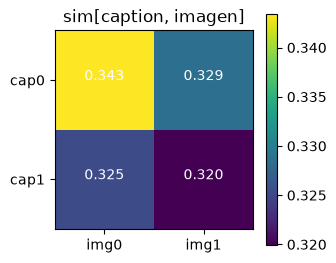

In [5]:
k=0
sim = cap[2*k:2*k+2] @ img[2*k:2*k+2].T
fig, axx = plt.subplots(figsize=(3.2,3))
im=axx.imshow(sim, cmap='viridis')
axx.set_xticks([0,1]); axx.set_xticklabels(['img0','img1']); axx.set_yticks([0,1]); axx.set_yticklabels(['cap0','cap1'])
for i in range(2):
    for j in range(2): axx.text(j,i,f'{sim[i,j]:.3f}',ha='center',color='w')
plt.colorbar(im); plt.title('sim[caption, imagen]'); plt.show()

## 4. El scorer (celda clave)
Reglas oficiales: **text** (fija imagen), **image** (fija caption), **group** (ambas). Azar: 1/4, 1/4, **1/6**.

In [6]:
from src.winoground_eval import text_correct, image_correct, group_correct, per_example_scores, aggregate
S = [cap[2*k:2*k+2] @ img[2*k:2*k+2].T for k in range(N)]
rows = per_example_scores(S)
df = pd.DataFrame(rows); df['tag']=tags
df.head(8)

,index,text,image,group,tag
0,0,0,0,0,Relation
1,1,0,0,0,Relation
2,2,1,0,0,Relation
3,3,0,0,0,Object
4,4,0,0,0,Relation
5,5,0,1,0,Object
6,6,0,0,0,Object
7,7,1,1,1,Object


## 5. Scores globales + intervalo de confianza (bootstrap)

In [7]:
from src.metrics import bootstrap_ci
agg = aggregate(S)
print(f'text={agg.text:.3f}  image={agg.image:.3f}  group={agg.group:.3f}  (azar group=1/6={1/6:.3f}; humano≈0.855)')
ci = {m: bootstrap_ci([r[m] for r in rows], rounds=2000, seed=42) for m in ['text','image','group']}
pd.DataFrame(ci).T[['mean','lo','hi']].round(3)

text=0.347  image=0.110  group=0.075  (azar group=1/6=0.167; humano≈0.855)


,mean,lo,hi
text,0.348,0.30,0.398
image,0.110,0.08,0.142
group,0.075,0.05,0.102


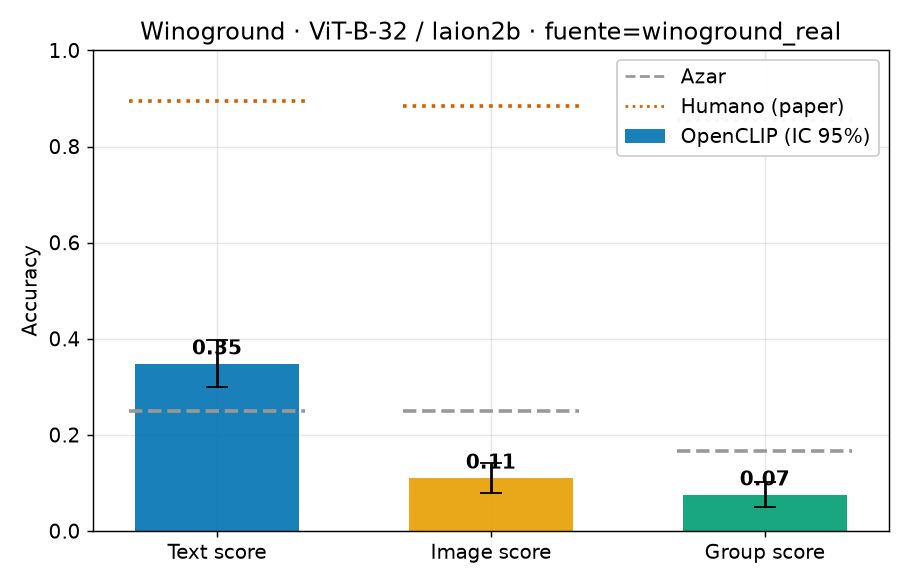

In [8]:
from IPython.display import Image, display
display(Image(filename=str(ROOT/'outputs'/'figures'/'scores_vs_chance.png')))

## 6. Validación del scorer (vs CLIP oficial)
Aplico mi scorer a `clip.jsonl` del dataset: debe dar **0.3075 / 0.1050 / 0.0800**.

In [9]:
from huggingface_hub import hf_hub_download
try:
    p = hf_hub_download('facebook/winoground','statistics/model_scores/clip.jsonl',
                        repo_type='dataset', cache_dir='data/winoground_cache')
    sc={}
    for line in open(p):
        r=json.loads(line); m=re.match(r'(\d+)_c(\d)_i(\d)',r['label'])
        sc.setdefault(int(m[1]),np.zeros((2,2)))[int(m[2]),int(m[3])]=r['score']
    a=aggregate([sc[k] for k in sorted(sc)])
    print(f'mi scorer -> text={a.text:.4f} image={a.image:.4f} group={a.group:.4f}  ✅ coincide')
except Exception as e:
    print('(dataset oficial no disponible:', type(e).__name__, ')')

mi scorer -> text=0.3075 image=0.1050 group=0.0800  ✅ coincide


## 7. Retrieval (R@K) — la otra cara
Recuperación con toda la galería (800 imágenes): el modelo es **bueno**, y eso oculta el problema.

In [10]:
from src.metrics import recall_at_k
full = cap @ img.T
t2i = recall_at_k(full, list(range(2*N)), ks=(1,5,10))
print('texto->imagen:', {k:round(v,3) for k,v in t2i.items() if k.startswith('R@')})
print('group score  :', round(agg.group,3), ' << R@5')

texto->imagen: {'R@1': 0.304, 'R@5': 0.667, 'R@10': 0.774}
group score  : 0.075  << R@5


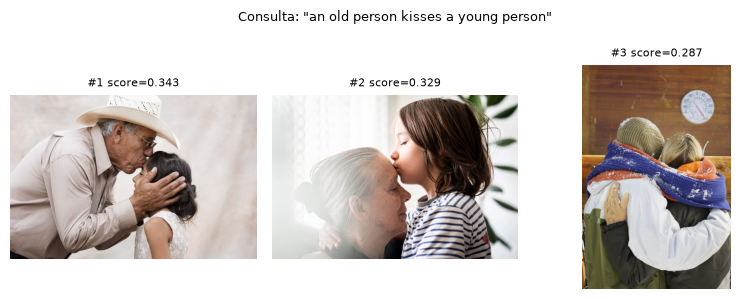

In [11]:
qj = 0
scoresq = (cap[qj] @ img.T); top = np.argsort(-scoresq)[:3]
fig, ax = plt.subplots(1,3, figsize=(8,3))
for r,g in enumerate(top):
    e=examples[g//2]; image = e.image_0 if g%2==0 else e.image_1
    ax[r].imshow(image); ax[r].set_title(f'#{r+1} score={scoresq[g]:.3f}', fontsize=8); ax[r].axis('off')
plt.suptitle(f'Consulta: "{examples[0].caption_0}"', fontsize=9); plt.tight_layout(); plt.show()

## 8. Análisis por tag (¿dónde falla?)

In [12]:
from src.error_analysis import scores_by_tag
scores_by_tag(S, tags)

,tag,text,image,group,n
2,Relation,0.304721,0.090129,0.047210,233
1,Object,0.390071,0.106383,0.085106,141
0,Both,0.500000,0.307692,0.269231,26


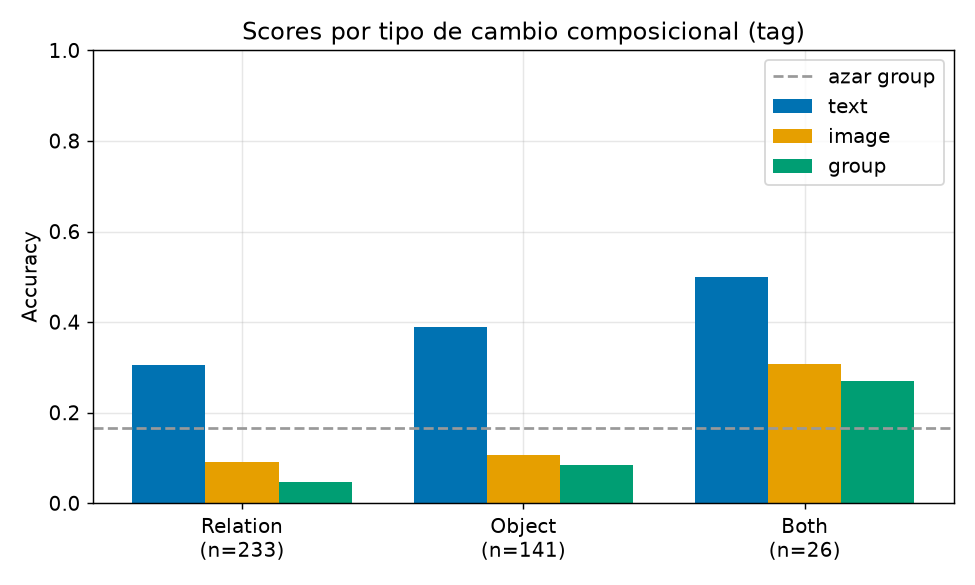

In [13]:
display(Image(filename=str(ROOT/'outputs'/'figures'/'by_tag.png')))

## 9. Prueba de ceguera (¿usa la imagen?)

real     : {'text_score': 0.347, 'image_score': 0.11, 'group_score': 0.075}
permutado: {'text_score': 0.135, 'image_score': 0.035, 'group_score': 0.015}


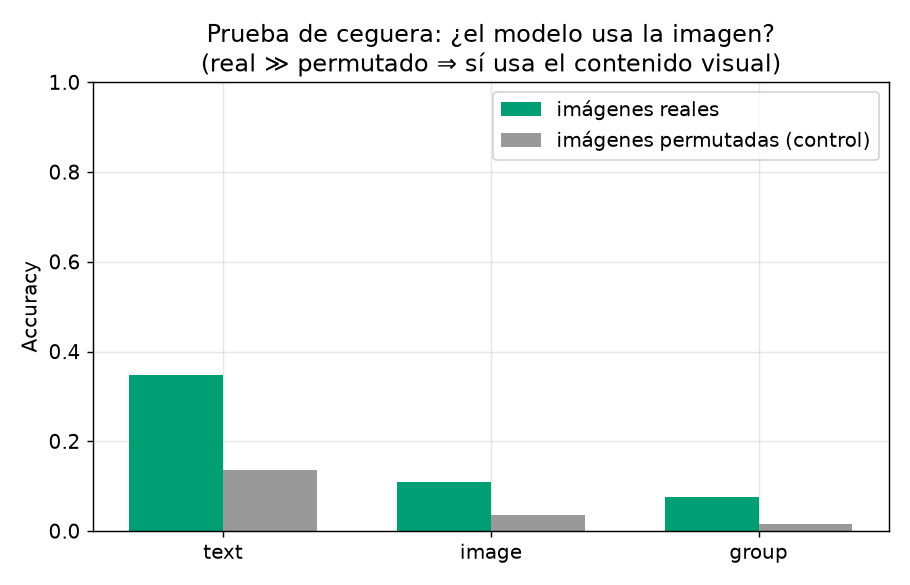

In [14]:
from src.blindness_probe import run_blindness_probe
cap_list=[cap[2*k:2*k+2] for k in range(N)]; img_list=[img[2*k:2*k+2] for k in range(N)]
b = run_blindness_probe(cap_list, img_list, seed=42)
print('real     :', {k:round(v,3) for k,v in b['real'].items() if 'score' in k})
print('permutado:', {k:round(v,3) for k,v in b['permuted_images'].items() if 'score' in k})
display(Image(filename=str(ROOT/'outputs'/'figures'/'blindness.png')))

## 10. Prompt ensembles (zero-shot, C10)
Envuelvo cada caption en plantillas y promedio embeddings (robustez).

In [15]:
model, prep, tok, dev = oc.create_model(*CKPT)
templates = ['{}', 'a photo of {}', 'an image showing {}']
def ensemble_text(txts):
    embs=[oc.encode_texts(model, tok, [t.format(x) for x in txts], dev) for t in templates]
    e=np.mean(embs, axis=0); return e/np.linalg.norm(e,axis=1,keepdims=True)
sub=range(50)
ens=[group_correct(ensemble_text([examples[k].caption_0, examples[k].caption_1]) @ img[2*k:2*k+2].T) for k in sub]
base=[rows[k]['group'] for k in sub]
print(f'group (50 ej.)  base={np.mean(base):.3f}  prompt-ensemble={np.mean(ens):.3f}')

group (50 ej.)  base=0.080  prompt-ensemble=0.100


## 11. Búsqueda semántica con FAISS (C10)

In [16]:
import faiss
index = faiss.IndexFlatIP(img.shape[1]); index.add(img.astype('float32'))
q = ensemble_text(['the old person kisses the young person'])[:1].astype('float32')
D,I = index.search(q, 3)
for rank,(g,s) in enumerate(zip(I[0],D[0]),1):
    e=examples[g//2]; capt=e.caption_0 if g%2==0 else e.caption_1
    print(f'#{rank} score={s:.3f}  ej={e.id}  ({"img0" if g%2==0 else "img1"}: {capt})')

#1 score=0.349  ej=0  (img0: an old person kisses a young person)
#2 score=0.341  ej=0  (img1: a young person kisses an old person)
#3 score=0.296  ej=318  (img0: two persons wearing one scarf)


## 12. Entreno un modelo: re-ranker composicional (mejora, C5/C6)
El dual-encoder compara por coseno (bolsa de conceptos). Entreno una cabeza pequeña que **mira la interacción** imagen-texto: `[t, v, t·v, |t−v|]` → MLP. Es un *cross-encoder-lite*.

**Rigor (validez):** uso **validación cruzada 5-fold** y reporto **media ± desviación** del group score (no un solo número). El split es **por ejemplo**, así que los 4 pares de un ejemplo nunca quedan a ambos lados (sin fuga de datos). Semillas fijas → replicable.
**Aviso honesto:** 400 ejemplos es poco; esto es **prueba de concepto** del método, no un número que supere a CLIP.

In [17]:
import torch, torch.nn as nn
from sklearn.model_selection import KFold
def feats(t, v):
    return np.concatenate([t, v, t*v, np.abs(t-v)], axis=-1)
def example_pairs(k):
    cc=cap[2*k:2*k+2]; vv=img[2*k:2*k+2]
    X=[feats(cc[ci],vv[ii]) for ci in range(2) for ii in range(2)]
    Y=[1.0 if ci==ii else 0.0 for ci in range(2) for ii in range(2)]
    return np.array(X,dtype='float32'), np.array(Y,dtype='float32')
def train_head(Xtr, Ytr, seed):
    torch.manual_seed(seed)
    net=nn.Sequential(nn.Linear(Xtr.shape[1],256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256,1))
    opt=torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4); lf=nn.BCEWithLogitsLoss()
    Xt=torch.tensor(Xtr); Yt=torch.tensor(Ytr).unsqueeze(1); hist=[]
    for _ in range(250):
        opt.zero_grad(); loss=lf(net(Xt),Yt); loss.backward(); opt.step(); hist.append(loss.item())
    return net, hist
print('helpers listos')

helpers listos


fold 0: zero-shot group=0.062  re-ranker group=0.113


fold 1: zero-shot group=0.100  re-ranker group=0.013


fold 2: zero-shot group=0.075  re-ranker group=0.025


fold 3: zero-shot group=0.062  re-ranker group=0.062


fold 4: zero-shot group=0.075  re-ranker group=0.037


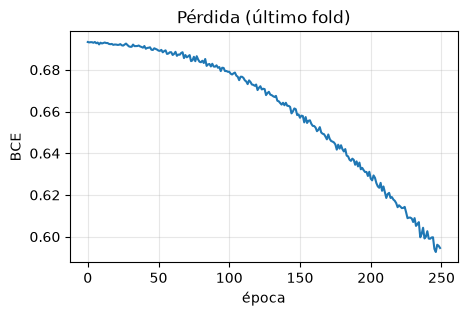

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
zs_g, rr_g, last_hist = [], [], None
for fold,(tr,te) in enumerate(kf.split(np.arange(N))):
    Xtr=np.concatenate([example_pairs(k)[0] for k in tr]); Ytr=np.concatenate([example_pairs(k)[1] for k in tr])
    net,last_hist = train_head(Xtr,Ytr, seed=42+fold)
    @torch.no_grad()
    def rr_M(k):
        cc=cap[2*k:2*k+2]; vv=img[2*k:2*k+2]
        return np.array([[torch.sigmoid(net(torch.tensor(feats(cc[ci],vv[ii])[None]))).item() for ii in range(2)] for ci in range(2)])
    zs_g.append(aggregate([cap[2*k:2*k+2] @ img[2*k:2*k+2].T for k in te]).group)
    rr_g.append(aggregate([rr_M(k) for k in te]).group)
    print(f'fold {fold}: zero-shot group={zs_g[-1]:.3f}  re-ranker group={rr_g[-1]:.3f}')
plt.figure(figsize=(5,3)); plt.plot(last_hist); plt.xlabel('época'); plt.ylabel('BCE'); plt.title('Pérdida (último fold)'); plt.grid(alpha=.3); plt.show()

In [19]:
zs_g, rr_g = np.array(zs_g), np.array(rr_g)
print(f'GROUP en test (5-fold CV):')
print(f'  zero-shot CLIP : {zs_g.mean():.3f} ± {zs_g.std():.3f}')
print(f'  re-ranker      : {rr_g.mean():.3f} ± {rr_g.std():.3f}')
print('\nLectura honesta: las barras de error se solapan -> con 400 ejemplos NO puedo afirmar')
print('que el re-ranker supere al zero-shot. Demuestra el MÉTODO (interacción imagen-texto)')
print('que un cross-encoder real (C5) escalaría con más datos. La CV evita concluir de más.')

GROUP en test (5-fold CV):
  zero-shot CLIP : 0.075 ± 0.014
  re-ranker      : 0.050 ± 0.035

Lectura honesta: las barras de error se solapan -> con 400 ejemplos NO puedo afirmar
que el re-ranker supere al zero-shot. Demuestra el MÉTODO (interacción imagen-texto)
que un cross-encoder real (C5) escalaría con más datos. La CV evita concluir de más.


## 13. Casos de error (group = 0)

0 | falló: text+image | cap0='an old person kisses a young person' vs cap1='a young person kisses an old person'
1 | falló: text+image | cap0='the taller person hugs the shorter person' vs cap1='the shorter person hugs the taller person'
2 | falló: image | cap0='the masked wrestler hits the unmasked wrestler' vs cap1='the unmasked wrestler hits the masked wrestler'


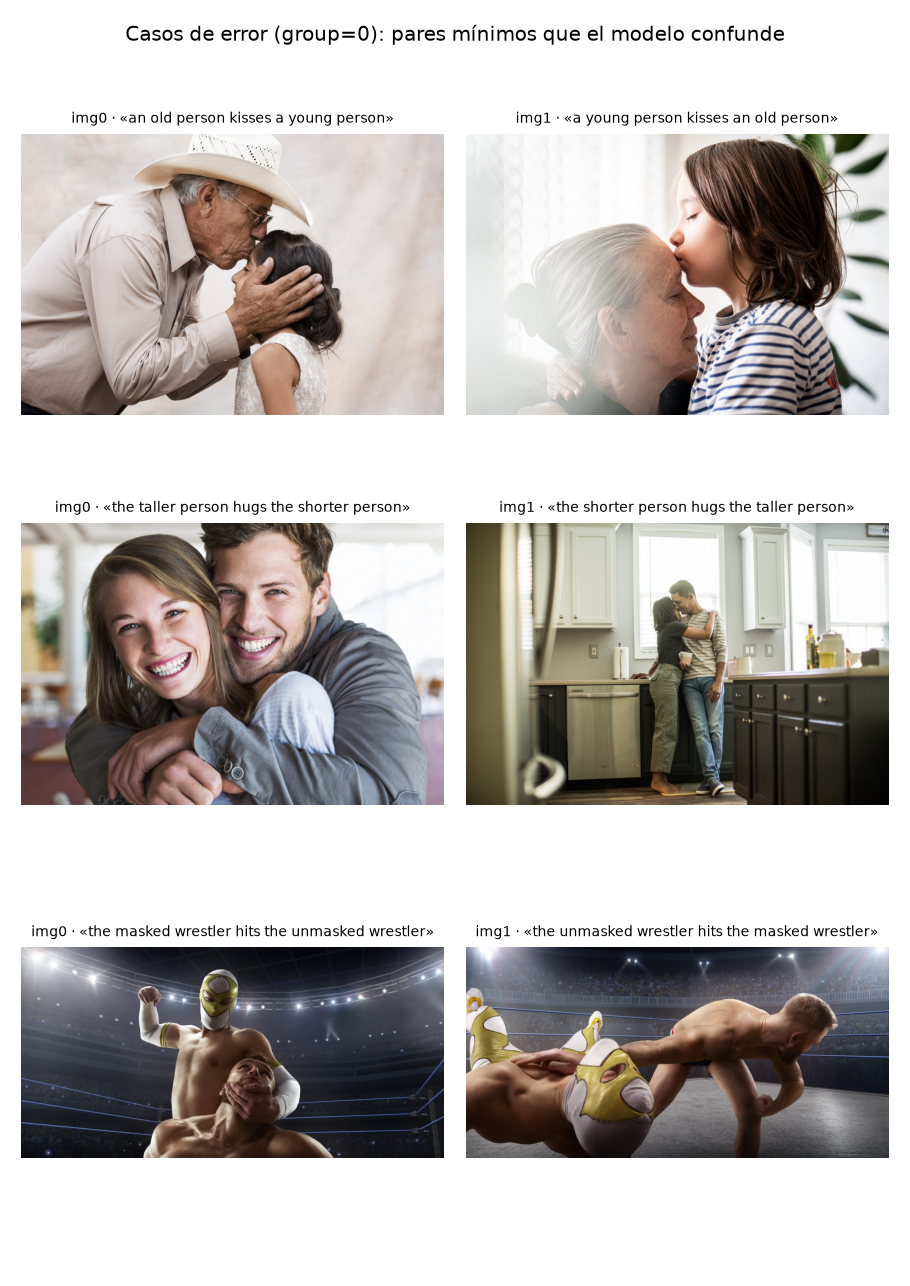

In [20]:
from src.error_analysis import failure_cases
for c0 in failure_cases(S, examples, max_cases=3):
    print(f"{c0['id']} | falló: {c0['failed']} | cap0='{c0['caption_0']}' vs cap1='{c0['caption_1']}'")
display(Image(filename=str(ROOT/'outputs'/'figures'/'qualitative_examples.png')))

## 14. Respuestas — 5 preguntas (8.6)
1. **Retrieval ≠ composición:** R@K usa toda la galería (fácil); group exige el par mínimo. R@5=0.67 vs group=0.075. Dual-encoder = bolsa de conceptos (C5).
2. **¿Usa la imagen?** Sí: la ceguera baja los scores (0.35→0.14). Límite composicional, no perceptivo (C8).
3. **Tipo de error:** vinculación, no reconocimiento. **Relation** lo peor (≈0.047).
4. **Adaptar el código:** `(img0,img1,cap0,cap1)`, permuto 2 tokens; el scorer arma la 2×2. Y entreno un re-ranker (sección 12) como mejora.
5. **Límite de métricas:** R@K/accuracy no miden composición; empates; azar group=1/6; benchmark con ruido (Diwan et al.).

## 15. §7 — generales (resumen)
- **Resultado reproducible:** scores (celda 5) + validación (celda 6).
- **Cuaderno usado/adaptado:** C10 (motor); nuevo = scorer + re-ranker.
- **Celdas clave:** 4 (scorer), 5 (scores), 12 (entrenamiento+CV).
- **Qué cambié vs C10:** tarea composicional + 5 análisis + entrenamiento con CV.
- **Limitación / mejora:** ruido del benchmark / cross-encoder real (C5, C6).
- **Si cambio checkpoint:** `checkpoint_comparison.csv` (no cierra la brecha).